# 🥭 EXP 02 — LR_1e3_Adam
## DenseNet169 | Transfer Learning (base congelada)
> ⚡ **Google Colab** — Activar GPU: `Entorno de ejecución → Cambiar tipo → T4 GPU`

| Hiperparámetro | Valor |
|---|---|
| Learning Rate | `0.001` |
| Batch Size | `32` |
| Épocas máx. | `50` |
| Optimizador | `Adam` |
| Dropout | `0.5` |
| Dense Units | `64` |
| L2 Regularización | `0.0001` |
| EarlyStopping patience | `10` |
| BatchNorm cabeza | `True` |
| Criterio mejor modelo | **F1-Score weighted** |

In [1]:
!pip install -q kagglehub seaborn scikit-learn
print('✅ Paquetes instalados')

✅ Paquetes instalados


In [2]:
import os, json, warnings, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
import tensorflow as tf
import kagglehub
from tensorflow import keras
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, Callback
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score, accuracy_score)
from sklearn.utils import class_weight
warnings.filterwarnings('ignore')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ─── Descarga del dataset (una sola vez) ──────────────────────────────────
kaggle_credentials = {
    'username': 'datasetdense169',
    'key': '58501601b86ccbf504958f6bff2df66b'
}
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

download_path = kagglehub.dataset_download('datasetdense169/datasetmangokent')
dataset_path  = os.path.join(download_path, 'DatasetV3_Roboflow')
train_dir = os.path.join(dataset_path, 'train')
val_dir   = os.path.join(dataset_path, 'valid')
test_dir  = os.path.join(dataset_path, 'test')

for split, path in [('train', train_dir), ('valid', val_dir), ('test', test_dir)]:
    if os.path.exists(path):
        clases = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
        total  = sum(len([f for f in os.listdir(os.path.join(path, c))
                          if f.lower().endswith(('.jpg','.jpeg','.png'))]) for c in clases)
        print(f'  ✓ {split:6s}: {total:>5} imgs | clases: {clases}')
    else:
        print(f'  ✗ {split} NO encontrado')

Using Colab cache for faster access to the 'datasetmangokent' dataset.
  ✓ train :  3096 imgs | clases: ['Defectuoso', 'Sanos']
  ✓ valid :   239 imgs | clases: ['Defectuoso', 'Sanos']
  ✓ test  :   316 imgs | clases: ['Defectuoso', 'Sanos']


In [4]:
# ─── Resultados de este experimento ─────────────────────────────────
RESULTS_TABLE = []  # tabla local para este experimento
print('✅ EXP 02 — LR_1e3_Adam — Notebook individual')
print('   Criterio de selección: F1-Score weighted en validación')

✅ EXP 02 — LR_1e3_Adam — Notebook individual
   Criterio de selección: F1-Score weighted en validación


In [5]:
# ─── Callback: Mejor modelo por F1-Score ────────────────────────────────
class BestF1Checkpoint(Callback):
    def __init__(self, val_ds, ckpt_path, verbose=1):
        super().__init__()
        self.val_ds    = val_ds
        self.ckpt_path = ckpt_path
        self.best_f1   = -1.0
        self.best_epoch = 0
        self.verbose   = verbose
        self.f1_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []
        for x_batch, y_batch in self.val_ds:
            preds = self.model.predict(x_batch, verbose=0)
            y_true.extend(y_batch.numpy().flatten().astype(int))
            y_pred.extend((preds.flatten() > 0.5).astype(int))
        current_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        self.f1_history.append(current_f1)
        if self.verbose:
            print(f'  val_f1_weighted: {current_f1:.4f}', end='')
        if current_f1 > self.best_f1:
            self.best_f1    = current_f1
            self.best_epoch = epoch + 1
            self.model.save_weights(self.ckpt_path)
            if self.verbose:
                print(f' ✅ Nuevo mejor F1 — pesos guardados')
        else:
            if self.verbose:
                print(f' (mejor: {self.best_f1:.4f} en época {self.best_epoch})')

    def on_train_end(self, logs=None):
        print(f'\n🏆 Mejor F1 en validación: {self.best_f1:.4f} (época {self.best_epoch})')
        print(f'   Restaurando mejores pesos...')
        self.model.load_weights(self.ckpt_path)
        print('   ✅ Pesos restaurados.')

print('✅ Callback BestF1Checkpoint definido')

✅ Callback BestF1Checkpoint definido


In [6]:
# ─── Función de construcción del modelo (Transfer Learning puro) ──────────
def get_optimizer():
    opt = CFG['OPTIMIZER']
    lr  = CFG['LR']
    if   opt == 'Adam'        : return keras.optimizers.Adam(learning_rate=lr)
    elif opt == 'Adamax'      : return keras.optimizers.Adamax(learning_rate=lr)
    elif opt == 'SGD'         : return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    elif opt == 'SGD_Nesterov': return keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    elif opt == 'RMSprop'     : return keras.optimizers.RMSprop(learning_rate=lr)
    else: raise ValueError(f'Optimizador desconocido: {opt}')

def build_model():
    base = DenseNet169(weights='imagenet', include_top=False,
                       input_shape=(CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3))
    base.trainable = False  # ← Transfer Learning puro: base CONGELADA

    inputs = keras.Input(shape=(CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3))
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D(name='gap')(x)
    if CFG['BN_HEAD']:
        x = BatchNormalization(name='bn_head')(x)
    x = Dropout(CFG['DROPOUT'], name='drop1')(x)
    x = Dense(CFG['DENSE_UNITS'], activation='relu',
              kernel_regularizer=keras.regularizers.l2(CFG['L2']),
              name='dense_head')(x)
    x = Dropout(CFG['DROPOUT'] * 0.6, name='drop2')(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name=f"DenseNet169_TL_EXP{CFG['EXPERIMENT_ID']:02d}")
    model.compile(
        optimizer=get_optimizer(),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

print('✅ Función build_model definida (Transfer Learning puro)')

✅ Función build_model definida (Transfer Learning puro)


In [7]:
# ─── Funciones de evaluación ─────────────────────────────────────────────
def evaluar(ds_prep, nombre):
    y_true, y_pred, y_prob = [], [], []
    for imgs, lbls in ds_prep:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(lbls.numpy().flatten())
        y_prob.extend(preds.flatten())
        y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    print(f"{'='*58}")
    print(f'  {nombre}')
    print(f"{'='*58}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    eps = 1e-7
    loss = -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))
    return y_true, y_pred, loss

def metrics_row(y_t, yp_t, y_v, yp_v, y_te_, yp_te_):
    acc_tr  = accuracy_score(y_t,   yp_t)
    acc_va  = accuracy_score(y_v,   yp_v)
    acc_te  = accuracy_score(y_te_, yp_te_)
    prec_tr = precision_score(y_t,   yp_t,   average='weighted', zero_division=0)
    prec_va = precision_score(y_v,   yp_v,   average='weighted', zero_division=0)
    prec_te = precision_score(y_te_, yp_te_, average='weighted', zero_division=0)
    rec_tr  = recall_score(y_t,   yp_t,   average='weighted', zero_division=0)
    rec_va  = recall_score(y_v,   yp_v,   average='weighted', zero_division=0)
    rec_te  = recall_score(y_te_, yp_te_, average='weighted', zero_division=0)
    f1_tr   = f1_score(y_t,   yp_t,   average='weighted', zero_division=0)
    f1_va   = f1_score(y_v,   yp_v,   average='weighted', zero_division=0)
    f1_te   = f1_score(y_te_, yp_te_, average='weighted', zero_division=0)
    return (acc_tr,acc_va,acc_te), (prec_tr,prec_va,prec_te), \
           (rec_tr,rec_va,rec_te), (f1_tr,f1_va,f1_te)

def plot_cm(y_true, y_pred, title, ax, cmap='Blues'):
    cm_ = confusion_matrix(y_true, y_pred)
    norm = cm_.astype(float) / cm_.sum(axis=1)[:,None]
    ann  = [[f'{v}\n({p:.1%})' for v,p in zip(r,rn)] for r,rn in zip(cm_,norm)]
    sns.heatmap(cm_, annot=ann, fmt='', cmap=cmap, ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size':11,'weight':'bold'})
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(f'Predicho\nAcc={acc:.4f}  F1={f1:.4f}')
    ax.set_ylabel('Real')

print('✅ Funciones de evaluación definidas')

✅ Funciones de evaluación definidas


In [8]:
# ─── Funciones Grad-CAM ──────────────────────────────────────────────────
def get_gradcam_heatmap(img_array, model, last_conv_layer_name='conv5_block32_2_conv'):
    base_model = model.get_layer('densenet169')
    last_conv = base_model.get_layer(last_conv_layer_name)
    base_grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[last_conv.output, base_model.output]
    )
    img_var = tf.Variable(tf.cast(img_array, tf.float32))
    with tf.GradientTape() as tape:
        conv_outputs, base_out = base_grad_model(img_var, training=False)
        x = base_out
        for lname in ['gap', 'bn_head', 'drop1', 'dense_head', 'drop2', 'output']:
            try:
                lyr = model.get_layer(lname)
                x = lyr(x, training=False)
            except Exception:
                pass
        loss = x[:, 0]
    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis],
                        (original_img.shape[0], original_img.shape[1]))
    ).squeeze()
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    jet_colors    = cm.get_cmap('jet')(np.arange(256))[:, :3]
    jet_heatmap   = jet_colors[heatmap_uint8]
    jet_heatmap   = np.uint8(jet_heatmap * 255)
    superimposed  = jet_heatmap * alpha + original_img * (1 - alpha)
    return np.uint8(superimposed)

print('✅ Funciones Grad-CAM definidas')

✅ Funciones Grad-CAM definidas


In [9]:
# ─── EXP 02: LR_1e3_Adam ─────────────────────────────────────────────
CFG = {
    'EXPERIMENT_ID'  : 2,
    'EXPERIMENT_NAME': 'LR_1e3_Adam',
    'DESCRIPCION'    : 'LR estándar Adam — línea base principal',

    # ── Rutas ──────────────────────────────────────────────────────
    'DATASET_VERSION': 'DatasetV3_Roboflow',

    # ── Imágenes ───────────────────────────────────────────────────
    'IMG_SIZE'  : 224,
    'BATCH_SIZE': 32,
    'SEED'      : 42,

    # ── Entrenamiento ──────────────────────────────────────────────
    'EPOCHS'    : 50,
    'LR'        : 0.001,
    'OPTIMIZER' : 'Adam',
    'PATIENCE'  : 10,
    'RLR_FACTOR': 0.5,

    # ── Arquitectura del head ──────────────────────────────────────
    'DENSE_UNITS': 64,
    'DROPOUT'    : 0.5,
    'L2'         : 0.0001,
    'BN_HEAD'    : True,

    # ── Grad-CAM ──────────────────────────────────────────────────
    'GRADCAM_SAMPLES': 8,
    'GRADCAM_ALPHA'  : 0.4,
}

tf.random.set_seed(CFG['SEED'])
np.random.seed(CFG['SEED'])
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('resultados',  exist_ok=True)

print('\n📋 CONFIGURACIÓN — EXP 02: LR_1e3_Adam')
for k, v in CFG.items():
    print(f'  {k:<20}: {v}')


📋 CONFIGURACIÓN — EXP 02: LR_1e3_Adam
  EXPERIMENT_ID       : 2
  EXPERIMENT_NAME     : LR_1e3_Adam
  DESCRIPCION         : LR estándar Adam — línea base principal
  DATASET_VERSION     : DatasetV3_Roboflow
  IMG_SIZE            : 224
  BATCH_SIZE          : 32
  SEED                : 42
  EPOCHS              : 50
  LR                  : 0.001
  OPTIMIZER           : Adam
  PATIENCE            : 10
  RLR_FACTOR          : 0.5
  DENSE_UNITS         : 64
  DROPOUT             : 0.5
  L2                  : 0.0001
  BN_HEAD             : True
  GRADCAM_SAMPLES     : 8
  GRADCAM_ALPHA       : 0.4


In [10]:
# ─── EXP 02: Carga y preprocesamiento ────────────────────────────
IMG  = CFG['IMG_SIZE']
BS   = CFG['BATCH_SIZE']
SEED = CFG['SEED']

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='binary',
    image_size=(IMG, IMG), batch_size=BS, shuffle=True, seed=SEED)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    val_dir,   labels='inferred', label_mode='binary',
    image_size=(IMG, IMG), batch_size=BS, shuffle=False)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,  labels='inferred', label_mode='binary',
    image_size=(IMG, IMG), batch_size=BS, shuffle=False)

class_names = train_ds_raw.class_names
preprocess_fn = tf.keras.applications.densenet.preprocess_input

def prepare(ds):
    ds = ds.map(lambda x, y: (preprocess_fn(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = prepare(train_ds_raw)
val_ds   = prepare(val_ds_raw)
test_ds  = prepare(test_ds_raw)

y_all = np.concatenate([y.numpy().flatten() for _, y in train_ds_raw])
cw    = class_weight.compute_class_weight('balanced', classes=np.unique(y_all), y=y_all)
class_weights_dict = dict(enumerate(cw))
print(f'Clases: {class_names}')
print(f'Pesos: { {class_names[k]: round(v,3) for k,v in class_weights_dict.items()} }')

Found 3096 files belonging to 2 classes.
Found 239 files belonging to 2 classes.
Found 316 files belonging to 2 classes.
Clases: ['Defectuoso', 'Sanos']
Pesos: {'Defectuoso': np.float64(1.008), 'Sanos': np.float64(0.992)}


In [11]:
# ─── EXP 02: Construcción del modelo ─────────────────────────────
model = build_model()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
total     = sum(tf.size(w).numpy() for w in model.weights)
print(f'Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Parámetros entrenables: 109,953 / 12,756,161 (0.86%)


In [12]:
# ─── EXP 02: Entrenamiento ────────────────────────────────────────
exp_name  = f"EXP{CFG['EXPERIMENT_ID']:02d}_{CFG['EXPERIMENT_NAME']}"
ckpt_path = f"checkpoints/best_{exp_name}.weights.h5"

f1_callback = BestF1Checkpoint(val_ds, ckpt_path, verbose=1)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=CFG['PATIENCE'],
                  restore_best_weights=False, verbose=1),
    f1_callback,
    ReduceLROnPlateau(monitor='val_loss', factor=CFG['RLR_FACTOR'],
                      patience=4, min_lr=1e-8, verbose=1),
    CSVLogger(f"resultados/log_{exp_name}.csv", append=False),
]

print(f'\n=== EXPERIMENTO {CFG["EXPERIMENT_ID"]:02d}: {CFG["EXPERIMENT_NAME"]} ===')
print(f'Desc: {CFG["DESCRIPCION"]}\n')

history = model.fit(
    train_ds, epochs=CFG['EPOCHS'],
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

print(f'\n{"="*55}')
print(f'🏆 MEJOR ÉPOCA (F1): {f1_callback.best_epoch}')
print(f'   Mejor Val F1      : {f1_callback.best_f1:.4f}')
print(f'{"="*55}')


=== EXPERIMENTO 02: LR_1e3_Adam ===
Desc: LR estándar Adam — línea base principal

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8232 - loss: 0.4299 - precision: 0.7969 - recall: 0.8324  val_f1_weighted: 0.8821 ✅ Nuevo mejor F1 — pesos guardados
97/97 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8666 - loss: 0.3403 - precision: 0.8376 - recall: 0.9122 - val_accuracy: 0.8828 - val_loss: 0.3081 - val_precision: 0.8333 - val_recall: 0.9583 - learning_rate: 0.0010
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9025 - loss: 0.2380 - precision: 0.8538 - recall: 0.9662  val_f1_weighted: 0.8818 (mejor: 0.8821 en época 1)
97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9008 - loss: 0.2372 - precision: 0.8640 - recall: 0.9532 - val_accuracy: 0.8828 - val_loss: 0.2821 - val_precision: 0.8239 - val_recall: 0.9750 - learning_rate: 0.0010
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9126 - loss: 0.2188 - precision: 0.8753 - recall

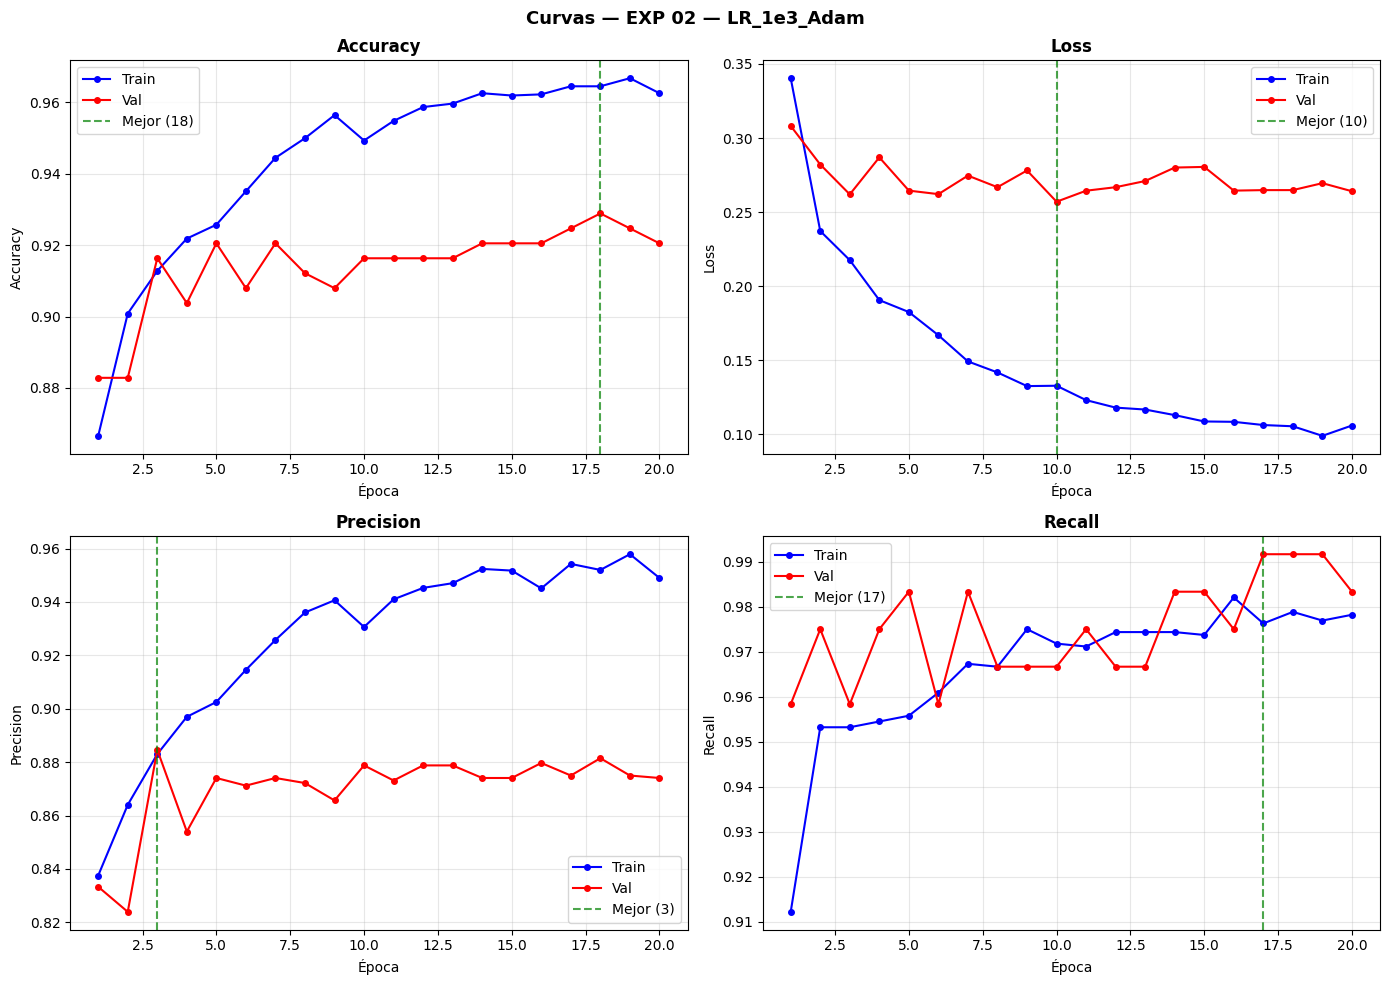

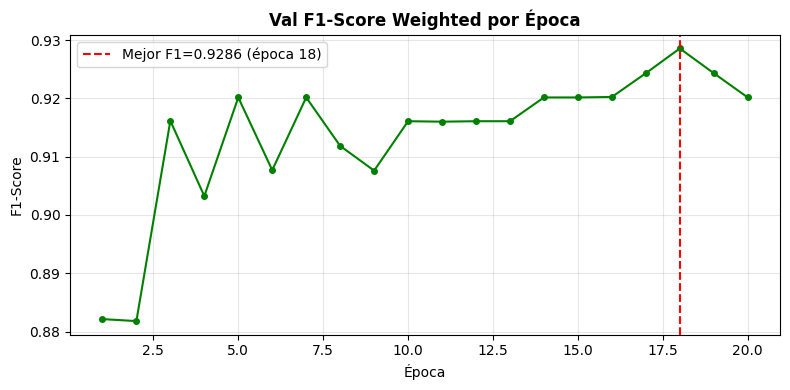

In [13]:
# ─── EXP 02: Curvas de entrenamiento ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
metrics_plot = [
    ('accuracy','val_accuracy','Accuracy'),
    ('loss','val_loss','Loss'),
    ('precision','val_precision','Precision'),
    ('recall','val_recall','Recall'),
]
for ax, (tk, vk, lbl) in zip(axes, metrics_plot):
    ep = range(1, len(history.history[tk])+1)
    ax.plot(ep, history.history[tk], 'b-o', ms=4, label='Train')
    ax.plot(ep, history.history[vk], 'r-o', ms=4, label='Val')
    be = int(np.argmin(history.history[vk]) if 'loss' in vk else np.argmax(history.history[vk]))
    ax.axvline(be+1, color='green', ls='--', alpha=0.7, label=f'Mejor ({be+1})')
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel(lbl)
    ax.legend(); ax.grid(True, alpha=0.3)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(range(1, len(f1_callback.f1_history)+1), f1_callback.f1_history, 'g-o', ms=4)
ax2.axvline(f1_callback.best_epoch, color='red', ls='--',
            label=f'Mejor F1={f1_callback.best_f1:.4f} (época {f1_callback.best_epoch})')
ax2.set_title('Val F1-Score Weighted por Época', fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('F1-Score')
ax2.legend(); ax2.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig(f'resultados/f1_curve_{exp_name}.png', dpi=130, bbox_inches='tight')

title = f"EXP {CFG['EXPERIMENT_ID']:02d} — {CFG['EXPERIMENT_NAME']}"
fig.suptitle(f'Curvas — {title}', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(f'resultados/curvas_{exp_name}.png', dpi=130, bbox_inches='tight')
plt.show()

In [14]:
# ─── EXP 02: Evaluación Train / Valid / Test ──────────────────────
y_tr, yp_tr, loss_tr = evaluar(train_ds, 'ENTRENAMIENTO')
y_va, yp_va, loss_va = evaluar(val_ds,   'VALIDACIÓN')
y_te, yp_te, loss_te = evaluar(test_ds,  'PRUEBA (Test) ★')

(acc_tr,acc_va,acc_te), (prec_tr,prec_va,prec_te), \
(rec_tr,rec_va,rec_te), (f1_tr,f1_va,f1_te) = metrics_row(
    y_tr, yp_tr, y_va, yp_va, y_te, yp_te)

print('\n' + '='*65)
print(f'  📊 EXP 02 — MÉTRICAS GLOBALES')
print('='*65)
print(f"{'Métrica':<28} {'Train':>10} {'Validación':>12} {'Test':>10}")
print('-'*65)
rows_exp = [
    ('Exactitud (Accuracy)',  acc_tr,  acc_va,  acc_te),
    ('Pérdida (BCE Loss)',    loss_tr, loss_va, loss_te),
    ('Precisión (Weighted)', prec_tr, prec_va, prec_te),
    ('Recall (Weighted)',    rec_tr,  rec_va,  rec_te),
    ('F1-Score (Weighted)',  f1_tr,   f1_va,   f1_te),
]
for label, tr, va, te in rows_exp:
    print(f"  {label:<26} {tr:>10.4f} {va:>12.4f} {te:>10.4f}")
print('='*65)
print(f"  {'★ Mejor época (F1)':<26} {f1_callback.best_epoch:>10}")
print(f"  {'★ Mejor val_f1':<26} {f1_callback.best_f1:>10.4f}")
print('='*65)

# Guardar resumen en tabla global
RESULTS_TABLE.append({
    'EXP': f'EXP02',
    'NOMBRE': 'LR_1e3_Adam',
    'LR': 0.001, 'BS': 32, 'DU': 64,
    'OPT': 'Adam', 'DROP': 0.5, 'L2': 0.0001, 'BN': True,
    'val_f1': round(f1_callback.best_f1, 4),
    'test_f1': round(f1_te, 4),
    'test_acc': round(acc_te, 4),
    'test_prec': round(prec_te, 4),
    'test_rec': round(rec_te, 4),
    'best_epoch': f1_callback.best_epoch,
})

  ENTRENAMIENTO
              precision    recall  f1-score   support

  Defectuoso     0.9987    0.9714    0.9848      1536
       Sanos     0.9725    0.9987    0.9855      1560

    accuracy                         0.9851      3096
   macro avg     0.9856    0.9850    0.9851      3096
weighted avg     0.9855    0.9851    0.9851      3096

  VALIDACIÓN
              precision    recall  f1-score   support

  Defectuoso     0.9904    0.8655    0.9238       119
       Sanos     0.8815    0.9917    0.9333       120

    accuracy                         0.9289       239
   macro avg     0.9359    0.9286    0.9286       239
weighted avg     0.9357    0.9289    0.9286       239

  PRUEBA (Test) ★
              precision    recall  f1-score   support

  Defectuoso     0.9932    0.9018    0.9453       163
       Sanos     0.9048    0.9935    0.9470       153

    accuracy                         0.9462       316
   macro avg     0.9490    0.9477    0.9462       316
weighted avg     0.9504    

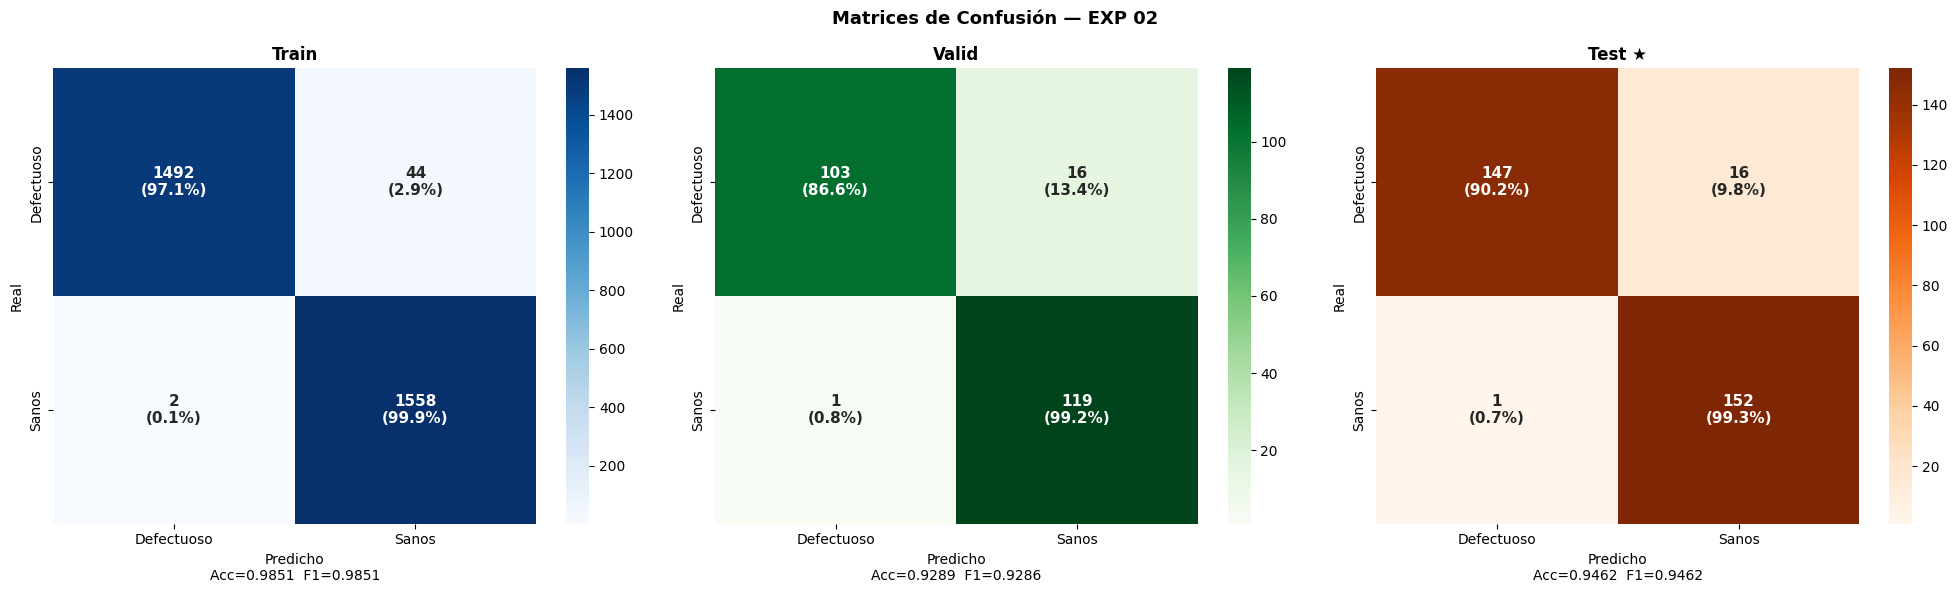

In [15]:
# ─── EXP 02: Matrices de confusión ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_cm(y_tr, yp_tr, 'Train',   axes[0], 'Blues')
plot_cm(y_va, yp_va, 'Valid',   axes[1], 'Greens')
plot_cm(y_te, yp_te, 'Test ★', axes[2], 'Oranges')
plt.suptitle(f"Matrices de Confusión — EXP 02",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'resultados/cm_{exp_name}.png', dpi=130, bbox_inches='tight')
plt.show()

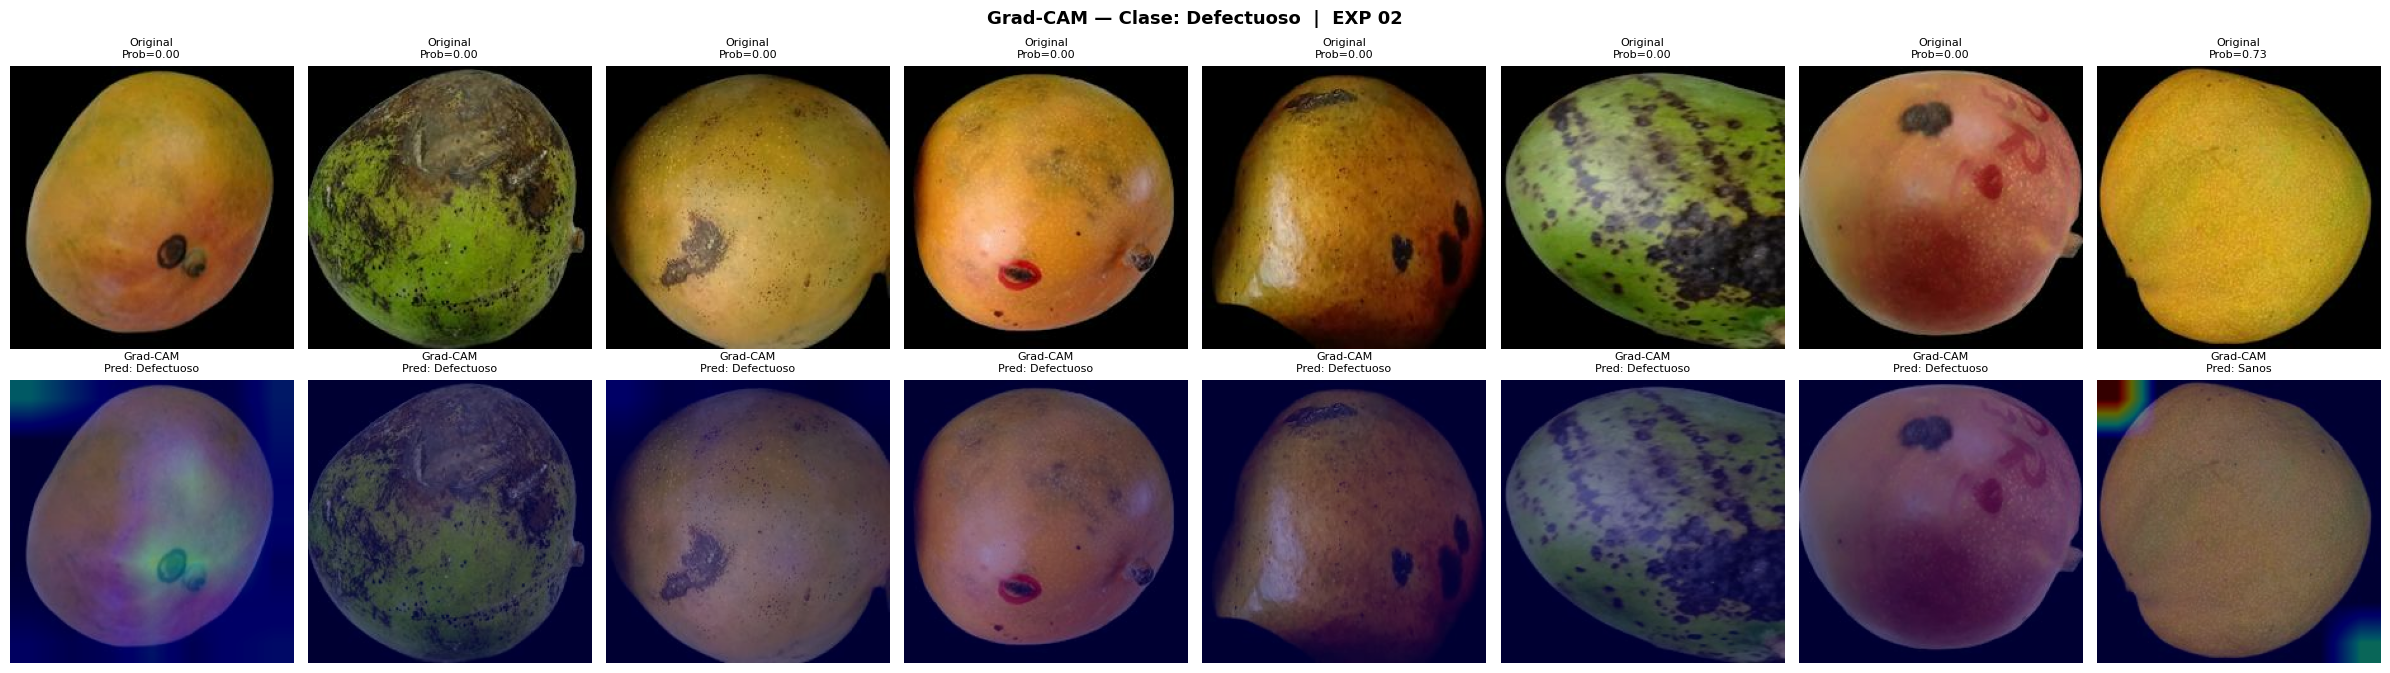

  💾 resultados/gradcam_EXP02_LR_1e3_Adam_Defectuoso.png


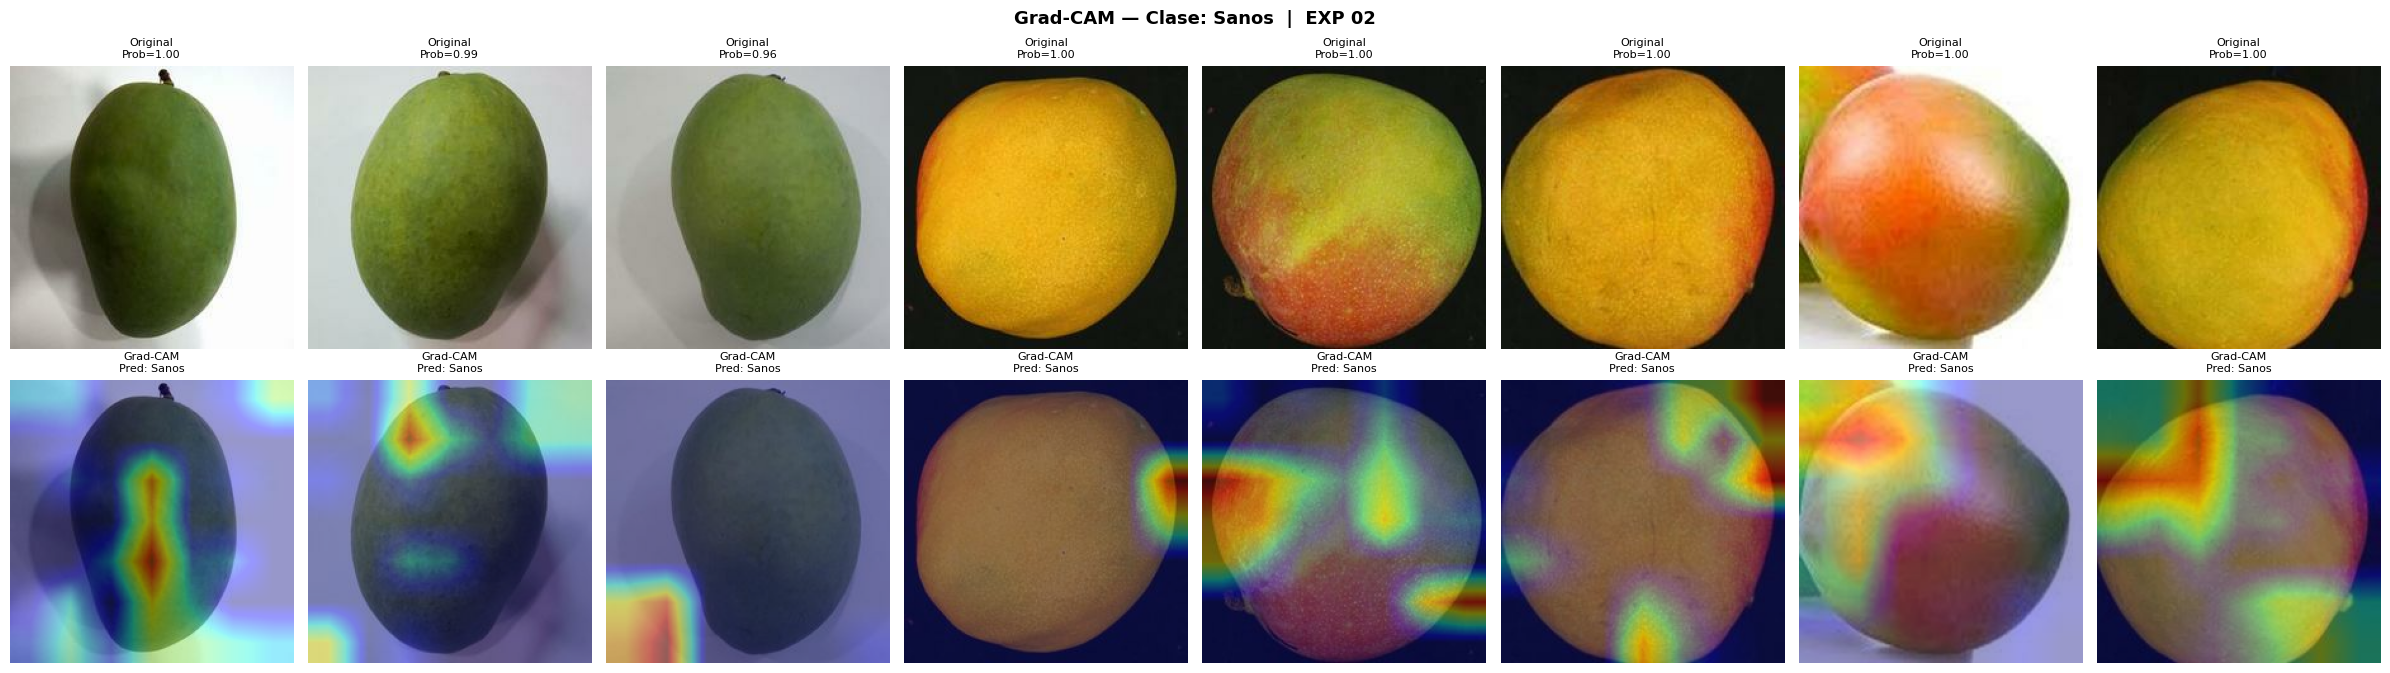

  💾 resultados/gradcam_EXP02_LR_1e3_Adam_Sanos.png


In [16]:
# ─── EXP 02: Grad-CAM ─────────────────────────────────────────────
LAST_CONV = 'conv5_block32_2_conv'
N = CFG['GRADCAM_SAMPLES']
samples = {0: [], 1: []}
for imgs_raw, lbls in test_ds_raw:
    imgs_prep_batch = preprocess_fn(tf.cast(imgs_raw, tf.float32))
    for img_raw, img_prep, lbl in zip(imgs_raw.numpy(), imgs_prep_batch.numpy(), lbls.numpy()):
        c = int(lbl)
        if len(samples[c]) < N:
            samples[c].append((img_raw.astype(np.uint8), img_prep))
    if all(len(v) >= N for v in samples.values()):
        break

ALPHA = CFG['GRADCAM_ALPHA']
for clase_idx, clase_name in enumerate(class_names):
    imgs_list = samples[clase_idx]
    n_cols = min(N, len(imgs_list))
    fig, axes = plt.subplots(2, n_cols, figsize=(3 * n_cols, 7))
    fig.suptitle(f'Grad-CAM — Clase: {clase_name}  |  EXP 02',
                 fontsize=13, fontweight='bold')
    for col, (img_orig, img_prep) in enumerate(imgs_list[:n_cols]):
        inp = img_prep[np.newaxis, ...].astype(np.float32)
        heatmap = get_gradcam_heatmap(inp, model, LAST_CONV)
        overlay = overlay_gradcam(img_orig, heatmap, alpha=ALPHA)
        prob    = model.predict(inp, verbose=0)[0][0]
        pred_name = class_names[int(prob > 0.5)]
        axes[0, col].imshow(img_orig)
        axes[0, col].set_title(f'Original\nProb={prob:.2f}', fontsize=8)
        axes[0, col].axis('off')
        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f'Grad-CAM\nPred: {pred_name}', fontsize=8)
        axes[1, col].axis('off')
    plt.tight_layout()
    fname = f'resultados/gradcam_{exp_name}_{clase_name}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'  💾 {fname}')

In [17]:
# ─── Resumen final EXP 02 ──────────────────────────────────────────
if RESULTS_TABLE:
    r = RESULTS_TABLE[0]
    print('\n' + '★'*60)
    print(f'  🏆 RESULTADO — EXP 02: LR_1e3_Adam')
    print('★'*60)
    for k, v in r.items():
        print(f'  {k:<16}: {v}')
    print('★'*60)
    df_exp = pd.DataFrame(RESULTS_TABLE)
    df_exp.to_csv(f'resultados/resumen_EXP02_LR_1e3_Adam.csv', index=False)
    print('\n💾 CSV guardado: resultados/resumen_EXP02_LR_1e3_Adam.csv')
else:
    print('⚠️ RESULTS_TABLE vacía — ejecuta las celdas anteriores primero')


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  🏆 RESULTADO — EXP 02: LR_1e3_Adam
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  EXP             : EXP02
  NOMBRE          : LR_1e3_Adam
  LR              : 0.001
  BS              : 32
  DU              : 64
  OPT             : Adam
  DROP            : 0.5
  L2              : 0.0001
  BN              : True
  val_f1          : 0.9286
  test_f1         : 0.9462
  test_acc        : 0.9462
  test_prec       : 0.9504
  test_rec        : 0.9462
  best_epoch      : 18
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

💾 CSV guardado: resultados/resumen_EXP02_LR_1e3_Adam.csv
